# 07e — Selected Peptide MM/GBSA-like Endpoint Comparison

## Pipeline 3 — Molecular Dynamics and energetic comparison

This notebook uses the **1 ns trajectories generated in 07d** for:

```text
F0010 = IGERCQYRDLK
CF06  = IGERCQYRELR
CF02  = IGERSQYRELK
```

and performs a **single-trajectory endpoint energy comparison**.

For each selected MD snapshot:

```text
ΔE_endpoint = E_complex - E_receptor - E_peptide
```

where the three energies are evaluated in the **same snapshot geometry**.

The notebook attempts to use an OpenMM implicit-solvent GB model together with
AMBER14SB. This provides an **MM/GBSA-like endpoint estimate**.

---

## Important scientific limitation

This is **not** a rigorous absolute binding free energy.

It does **not** include:
- conformational entropy;
- independent receptor/peptide relaxation;
- multiple independent MD replicates;
- long-timescale convergence;
- experimental calibration.

Therefore, interpret the result as a **comparative energetic proxy** across
F0010, CF06 and CF02.

More negative endpoint energies are interpreted as more favorable within this
specific protocol.


## 1. Imports

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import MDAnalysis as mda

from openmm import (
    Platform,
    unit,
)
from openmm.app import (
    PDBFile,
    Modeller,
    ForceField,
    Simulation,
    NoCutoff,
)
from openmm import VerletIntegrator

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Imports OK")


Imports OK


## 2. Configuration

In [2]:
CANDIDATES = {
    "F0010": "IGERCQYRDLK",
    "CF06": "IGERCQYRELR",
    "CF02": "IGERSQYRELK",
}

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

RUN_07D = "production_1ns"

INPUT_ROOT = (
    Path("outputs")
    / "pipeline_3_md_07d_selected_peptide_comparison"
    / RUN_07D
)

OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_3_md_07e_mmgbsa_endpoint_comparison"
)

TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [OUTPUT_ROOT, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Number of snapshots sampled uniformly from each 1 ns trajectory.
N_SNAPSHOTS = 50

# OpenMM protein force field.
PROTEIN_FF = "amber14/protein.ff14SB.xml"

# Candidate implicit-solvent XML files.
# The notebook will test these in order and use the first available/compatible one.
IMPLICIT_SOLVENT_CANDIDATES = [
    "implicit/gbn2.xml",
    "implicit/obc2.xml",
    "amber99_obc.xml",
]

print("07d input:", INPUT_ROOT.resolve())
print("07e output:", OUTPUT_ROOT.resolve())
print("Snapshots per candidate:", N_SNAPSHOTS)


07d input: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07d_selected_peptide_comparison/production_1ns
07e output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07e_mmgbsa_endpoint_comparison
Snapshots per candidate: 50


## 3. Locate and validate 07d trajectories

In [3]:
input_rows = []
candidate_inputs = {}

for name in CANDIDATES:
    candidate_dir = INPUT_ROOT / name

    topology = (
        candidate_dir
        / "trajectory"
        / f"{name}_protein_topology.pdb"
    )

    trajectory = (
        candidate_dir
        / "trajectory"
        / f"{name}_{RUN_07D}_protein.dcd"
    )

    contacts = (
        candidate_dir
        / "analysis"
        / "BD_contact_persistence.csv"
    )

    candidate_inputs[name] = {
        "topology": topology,
        "trajectory": trajectory,
        "contacts": contacts,
    }

    input_rows.append({
        "candidate": name,
        "topology": str(topology),
        "topology_exists": topology.exists(),
        "trajectory": str(trajectory),
        "trajectory_exists": trajectory.exists(),
        "contacts_exists": contacts.exists(),
    })

input_check_df = pd.DataFrame(input_rows)

display(input_check_df)

if not (
    input_check_df["topology_exists"].all()
    and input_check_df["trajectory_exists"].all()
):
    raise FileNotFoundError(
        "One or more 07d production_1ns topology/DCD files are missing."
    )

print("07d trajectory input check: PASS")


,candidate,topology,topology_exists,trajectory,trajectory_exists,contacts_exists
0,F0010,outputs/pipeline_3_md_07d_selected_peptide_com...,True,outputs/pipeline_3_md_07d_selected_peptide_com...,True,True
1,CF06,outputs/pipeline_3_md_07d_selected_peptide_com...,True,outputs/pipeline_3_md_07d_selected_peptide_com...,True,True
2,CF02,outputs/pipeline_3_md_07d_selected_peptide_com...,True,outputs/pipeline_3_md_07d_selected_peptide_com...,True,True


07d trajectory input check: PASS


## 4. Verify trajectory size and peptide sequences

In [4]:
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

trajectory_validation = []

for name, paths in candidate_inputs.items():

    u = mda.Universe(
        str(paths["topology"]),
        str(paths["trajectory"]),
    )

    chain_ids = set(
        str(x)
        for x in u.atoms.chainIDs
    )

    if PEPTIDE_CHAIN in chain_ids:
        peptide = u.select_atoms(
            f"chainID {PEPTIDE_CHAIN}"
        )
    else:
        peptide = u.select_atoms(
            f"segid {PEPTIDE_CHAIN}"
        )

    sequence = "".join(
        THREE_TO_ONE.get(
            residue.resname.upper(),
            "",
        )
        for residue in peptide.residues
    )

    trajectory_validation.append({
        "candidate": name,
        "n_frames": len(u.trajectory),
        "n_atoms": len(u.atoms),
        "observed_sequence": sequence,
        "expected_sequence": CANDIDATES[name],
        "sequence_match": (
            sequence == CANDIDATES[name]
        ),
    })

trajectory_validation_df = pd.DataFrame(
    trajectory_validation
)

display(trajectory_validation_df)

if not trajectory_validation_df["sequence_match"].all():
    raise RuntimeError(
        "At least one peptide sequence does not match the expected candidate."
    )

if not (
    trajectory_validation_df["n_frames"] >= N_SNAPSHOTS
).all():
    raise RuntimeError(
        "N_SNAPSHOTS exceeds the available trajectory frame count."
    )

print("Trajectory validation: PASS")


,candidate,n_frames,n_atoms,observed_sequence,expected_sequence,sequence_match
0,F0010,500,9480,IGERCQYRDLK,IGERCQYRDLK,True
1,CF06,500,9485,IGERCQYRELR,IGERCQYRELR,True
2,CF02,500,9483,IGERSQYRELK,IGERSQYRELK,True


Trajectory validation: PASS


## 5. Detect a compatible OpenMM implicit-solvent model

The exact XML files available depend on the OpenMM installation.

The notebook tries several standard implicit-solvent definitions and uses the
first one that can parameterize the F0010 complex.

If none is available, the notebook stops rather than silently falling back to
a different physical model.


In [5]:
def build_test_forcefield(
    protein_ff,
    implicit_ff,
):
    return ForceField(
        protein_ff,
        implicit_ff,
    )

reference_pdb = (
    candidate_inputs["F0010"]["topology"]
)

reference = PDBFile(
    str(reference_pdb)
)

implicit_test_rows = []
SELECTED_IMPLICIT_FF = None

for implicit_ff in IMPLICIT_SOLVENT_CANDIDATES:
    try:
        ff = build_test_forcefield(
            PROTEIN_FF,
            implicit_ff,
        )

        test_system = ff.createSystem(
            reference.topology,
            nonbondedMethod=NoCutoff,
            constraints=None,
        )

        implicit_test_rows.append({
            "implicit_ff": implicit_ff,
            "status": "PASS",
            "message": "",
        })

        SELECTED_IMPLICIT_FF = implicit_ff
        break

    except Exception as exc:
        implicit_test_rows.append({
            "implicit_ff": implicit_ff,
            "status": "FAIL",
            "message": str(exc)[:300],
        })

implicit_test_df = pd.DataFrame(
    implicit_test_rows
)

display(implicit_test_df)

if SELECTED_IMPLICIT_FF is None:
    raise RuntimeError(
        "No compatible implicit-solvent XML was found in this OpenMM environment."
    )

print("Selected implicit-solvent model:", SELECTED_IMPLICIT_FF)


,implicit_ff,status,message
0,implicit/gbn2.xml,PASS,


Selected implicit-solvent model: implicit/gbn2.xml


## 6. Select OpenMM platform

In [6]:
def choose_platform():
    available = [
        Platform.getPlatform(i).getName()
        for i in range(
            Platform.getNumPlatforms()
        )
    ]

    for preferred in [
        "CUDA",
        "OpenCL",
        "CPU",
        "Reference",
    ]:
        if preferred in available:
            return Platform.getPlatformByName(
                preferred
            )

    raise RuntimeError(
        "No OpenMM platform available."
    )

platform = choose_platform()

print("OpenMM platform:", platform.getName())


OpenMM platform: OpenCL


## 7. Helper — split complex topology into receptor and peptide

For each candidate the protein-only topology from 07d is divided into:

```text
complex   = chain B + chain D
receptor  = chain B
peptide   = chain D
```

All three energies are evaluated using coordinates from the same MD snapshot.


In [7]:
def make_component_modeller(
    pdb_file,
    keep_chains,
):
    modeller = Modeller(
        pdb_file.topology,
        pdb_file.positions,
    )

    atoms_to_delete = [
        atom
        for atom in modeller.topology.atoms()
        if atom.residue.chain.id
        not in set(keep_chains)
    ]

    if atoms_to_delete:
        modeller.delete(
            atoms_to_delete
        )

    return modeller


## 8. Helper — build endpoint-energy systems

In [8]:
def make_forcefield():
    return ForceField(
        PROTEIN_FF,
        SELECTED_IMPLICIT_FF,
    )

def create_energy_system(
    topology,
):
    ff = make_forcefield()

    return ff.createSystem(
        topology,
        nonbondedMethod=NoCutoff,
        constraints=None,
    )

def create_energy_simulation(
    topology,
    system,
):
    integrator = VerletIntegrator(
        0.001 * unit.picoseconds
    )

    simulation = Simulation(
        topology,
        system,
        integrator,
        platform,
    )

    return simulation


## 9. Helper — evaluate one component energy

The value returned is the total potential energy of the component in
`kcal/mol`.

The same coordinates are used for the complex and its separated components,
which corresponds to a **single-trajectory endpoint decomposition**.


In [9]:
def potential_energy_kcal(
    simulation,
    positions,
):
    simulation.context.setPositions(
        positions
    )

    state = simulation.context.getState(
        getEnergy=True
    )

    energy = state.getPotentialEnergy()

    return float(
        energy.value_in_unit(
            unit.kilocalories_per_mole
        )
    )


## 10. Build energy evaluators for each candidate

In [10]:
energy_models = {}

for name, paths in candidate_inputs.items():

    print("Building endpoint systems:", name)

    pdb = PDBFile(
        str(paths["topology"])
    )

    complex_modeller = make_component_modeller(
        pdb,
        [RECEPTOR_CHAIN, PEPTIDE_CHAIN],
    )

    receptor_modeller = make_component_modeller(
        pdb,
        [RECEPTOR_CHAIN],
    )

    peptide_modeller = make_component_modeller(
        pdb,
        [PEPTIDE_CHAIN],
    )

    complex_system = create_energy_system(
        complex_modeller.topology
    )

    receptor_system = create_energy_system(
        receptor_modeller.topology
    )

    peptide_system = create_energy_system(
        peptide_modeller.topology
    )

    energy_models[name] = {
        "complex_modeller": complex_modeller,
        "receptor_modeller": receptor_modeller,
        "peptide_modeller": peptide_modeller,
        "complex_sim": create_energy_simulation(
            complex_modeller.topology,
            complex_system,
        ),
        "receptor_sim": create_energy_simulation(
            receptor_modeller.topology,
            receptor_system,
        ),
        "peptide_sim": create_energy_simulation(
            peptide_modeller.topology,
            peptide_system,
        ),
    }

print("All energy evaluators built.")


Building endpoint systems: F0010
Building endpoint systems: CF06
Building endpoint systems: CF02
All energy evaluators built.


## 11. Determine atom indices for receptor and peptide

MDAnalysis and OpenMM must use exactly the same atom order.

The notebook checks this using chain membership from the protein topology.


In [11]:
component_indices = {}

for name, paths in candidate_inputs.items():

    u = mda.Universe(
        str(paths["topology"])
    )

    chain_ids = np.array(
        [
            str(x)
            for x in u.atoms.chainIDs
        ]
    )

    receptor_idx = np.where(
        chain_ids == RECEPTOR_CHAIN
    )[0]

    peptide_idx = np.where(
        chain_ids == PEPTIDE_CHAIN
    )[0]

    if len(receptor_idx) == 0 or len(peptide_idx) == 0:
        raise RuntimeError(
            f"Could not identify B/D atom indices for {name}."
        )

    component_indices[name] = {
        "receptor": receptor_idx,
        "peptide": peptide_idx,
    }

    print(
        name,
        "| receptor atoms:",
        len(receptor_idx),
        "| peptide atoms:",
        len(peptide_idx),
    )


F0010 | receptor atoms: 9286 | peptide atoms: 194
CF06 | receptor atoms: 9286 | peptide atoms: 199
CF02 | receptor atoms: 9286 | peptide atoms: 197


## 12. Select uniformly spaced snapshots

In [12]:
snapshot_frames = {}

for name, paths in candidate_inputs.items():

    u = mda.Universe(
        str(paths["topology"]),
        str(paths["trajectory"]),
    )

    n_frames = len(
        u.trajectory
    )

    selected = np.linspace(
        0,
        n_frames - 1,
        N_SNAPSHOTS,
        dtype=int,
    )

    selected = np.unique(
        selected
    )

    snapshot_frames[name] = selected

    print(
        name,
        "| available:",
        n_frames,
        "| selected:",
        len(selected),
        "| first/last:",
        selected[0],
        selected[-1],
    )


F0010 | available: 500 | selected: 50 | first/last: 0 499
CF06 | available: 500 | selected: 50 | first/last: 0 499
CF02 | available: 500 | selected: 50 | first/last: 0 499


## 13. Endpoint-energy calculation

For each selected snapshot:

```text
E_complex
E_receptor
E_peptide

ΔE_endpoint = E_complex - E_receptor - E_peptide
```

More negative values are more favorable **within this protocol**.


In [13]:
all_energy_rows = []

for name, paths in candidate_inputs.items():

    print("\nEvaluating:", name)

    u = mda.Universe(
        str(paths["topology"]),
        str(paths["trajectory"]),
    )

    idx_B = component_indices[name][
        "receptor"
    ]

    idx_D = component_indices[name][
        "peptide"
    ]

    model = energy_models[name]

    for count, frame_idx in enumerate(
        snapshot_frames[name],
        start=1,
    ):

        u.trajectory[
            int(frame_idx)
        ]

        # MDAnalysis positions are Angstrom.
        xyz_A = u.atoms.positions.copy()

        complex_positions = (
            xyz_A
            * unit.angstrom
        )

        receptor_positions = (
            xyz_A[idx_B]
            * unit.angstrom
        )

        peptide_positions = (
            xyz_A[idx_D]
            * unit.angstrom
        )

        E_complex = potential_energy_kcal(
            model["complex_sim"],
            complex_positions,
        )

        E_receptor = potential_energy_kcal(
            model["receptor_sim"],
            receptor_positions,
        )

        E_peptide = potential_energy_kcal(
            model["peptide_sim"],
            peptide_positions,
        )

        delta_E = (
            E_complex
            - E_receptor
            - E_peptide
        )

        all_energy_rows.append({
            "candidate": name,
            "snapshot_index": count,
            "frame": int(frame_idx),
            "time_ps": float(
                u.trajectory.ts.time
            ),
            "E_complex_kcal_mol": E_complex,
            "E_receptor_kcal_mol": E_receptor,
            "E_peptide_kcal_mol": E_peptide,
            "delta_E_endpoint_kcal_mol": delta_E,
        })

        if (
            count == 1
            or count % 10 == 0
            or count == len(
                snapshot_frames[name]
            )
        ):
            print(
                f"  snapshot {count:>2}/"
                f"{len(snapshot_frames[name])}"
                f" | frame {frame_idx:>3}"
                f" | ΔE={delta_E:8.2f} kcal/mol"
            )

energy_df = pd.DataFrame(
    all_energy_rows
)

energy_df.to_csv(
    TABLE_DIR
    / "07e_snapshot_endpoint_energies.csv",
    index=False,
)

print("\nEndpoint calculation complete.")
display(energy_df.head())



Evaluating: F0010
  snapshot  1/50 | frame   0 | ΔE=  -66.18 kcal/mol
  snapshot 10/50 | frame  91 | ΔE=  -65.33 kcal/mol
  snapshot 20/50 | frame 193 | ΔE=  -56.91 kcal/mol
  snapshot 30/50 | frame 295 | ΔE=  -63.96 kcal/mol
  snapshot 40/50 | frame 397 | ΔE=  -53.15 kcal/mol
  snapshot 50/50 | frame 499 | ΔE=  -52.57 kcal/mol

Evaluating: CF06
  snapshot  1/50 | frame   0 | ΔE=  -59.97 kcal/mol
  snapshot 10/50 | frame  91 | ΔE=  -57.54 kcal/mol
  snapshot 20/50 | frame 193 | ΔE=  -65.74 kcal/mol
  snapshot 30/50 | frame 295 | ΔE=  -69.19 kcal/mol
  snapshot 40/50 | frame 397 | ΔE=  -61.45 kcal/mol
  snapshot 50/50 | frame 499 | ΔE=  -59.74 kcal/mol

Evaluating: CF02
  snapshot  1/50 | frame   0 | ΔE=  -49.03 kcal/mol
  snapshot 10/50 | frame  91 | ΔE=  -59.41 kcal/mol
  snapshot 20/50 | frame 193 | ΔE=  -58.30 kcal/mol
  snapshot 30/50 | frame 295 | ΔE=  -51.40 kcal/mol
  snapshot 40/50 | frame 397 | ΔE=  -65.15 kcal/mol
  snapshot 50/50 | frame 499 | ΔE=  -58.95 kcal/mol

Endpoint

,candidate,snapshot_index,frame,time_ps,E_complex_kcal_mol,E_receptor_kcal_mol,E_peptide_kcal_mol,delta_E_endpoint_kcal_mol
0,F0010,1,0,2.0,-14604.134605,-13883.426732,-654.527186,-66.180687
1,F0010,2,10,22.0,-14741.574814,-14038.072502,-640.945240,-62.557072
2,F0010,3,20,42.0,-14571.049138,-13831.323263,-672.938986,-66.786889
3,F0010,4,30,62.0,-14704.545446,-13990.999853,-649.859600,-63.685994
4,F0010,5,40,82.0,-14679.328904,-13954.296951,-658.950769,-66.081185


## 14. QC — finite energies and snapshot counts

In [14]:
qc_rows = []

for name in CANDIDATES:

    df = energy_df[
        energy_df["candidate"]
        == name
    ]

    finite = np.isfinite(
        df[
            [
                "E_complex_kcal_mol",
                "E_receptor_kcal_mol",
                "E_peptide_kcal_mol",
                "delta_E_endpoint_kcal_mol",
            ]
        ].values
    ).all()

    qc_rows.append({
        "candidate": name,
        "n_snapshots": len(df),
        "all_energies_finite": bool(finite),
        "snapshot_count_OK": (
            len(df)
            == len(
                snapshot_frames[name]
            )
        ),
    })

qc_df = pd.DataFrame(
    qc_rows
)

qc_df["QC_PASS"] = (
    qc_df["all_energies_finite"]
    & qc_df["snapshot_count_OK"]
)

display(qc_df)

print(
    "ALL QC PASSED:",
    bool(
        qc_df["QC_PASS"].all()
    ),
)


,candidate,n_snapshots,all_energies_finite,snapshot_count_OK,QC_PASS
0,F0010,50,True,True,True
1,CF06,50,True,True,True
2,CF02,50,True,True,True


ALL QC PASSED: True


## 15. Candidate endpoint-energy summary

In [15]:
summary_rows = []

for name in CANDIDATES:

    values = (
        energy_df.loc[
            energy_df["candidate"]
            == name,
            "delta_E_endpoint_kcal_mol",
        ]
        .astype(float)
    )

    summary_rows.append({
        "candidate": name,
        "sequence": CANDIDATES[name],
        "n_snapshots": len(values),
        "mean_delta_E_endpoint_kcal_mol": values.mean(),
        "sd_delta_E_endpoint_kcal_mol": values.std(ddof=1),
        "median_delta_E_endpoint_kcal_mol": values.median(),
        "min_delta_E_endpoint_kcal_mol": values.min(),
        "max_delta_E_endpoint_kcal_mol": values.max(),
        "sem_delta_E_endpoint_kcal_mol": (
            values.std(ddof=1)
            / np.sqrt(len(values))
        ),
    })

summary_df = pd.DataFrame(
    summary_rows
)

summary_df = summary_df.sort_values(
    "mean_delta_E_endpoint_kcal_mol",
    ascending=True,
).reset_index(drop=True)

summary_df.insert(
    0,
    "energetic_rank",
    np.arange(
        len(summary_df)
    ) + 1,
)

summary_df.to_csv(
    TABLE_DIR
    / "07e_endpoint_energy_summary.csv",
    index=False,
)

display(summary_df)


,energetic_rank,candidate,sequence,n_snapshots,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,median_delta_E_endpoint_kcal_mol,min_delta_E_endpoint_kcal_mol,max_delta_E_endpoint_kcal_mol,sem_delta_E_endpoint_kcal_mol
0,1,CF06,IGERCQYRELR,50,-65.661216,6.801657,-65.604063,-79.576170,-52.041251,0.961900
1,2,F0010,IGERCQYRDLK,50,-59.457704,5.958218,-59.030358,-70.545746,-50.107900,0.842619
2,3,CF02,IGERSQYRELK,50,-56.619600,4.628475,-56.272921,-65.955437,-45.994941,0.654565


## 16. Energy distributions

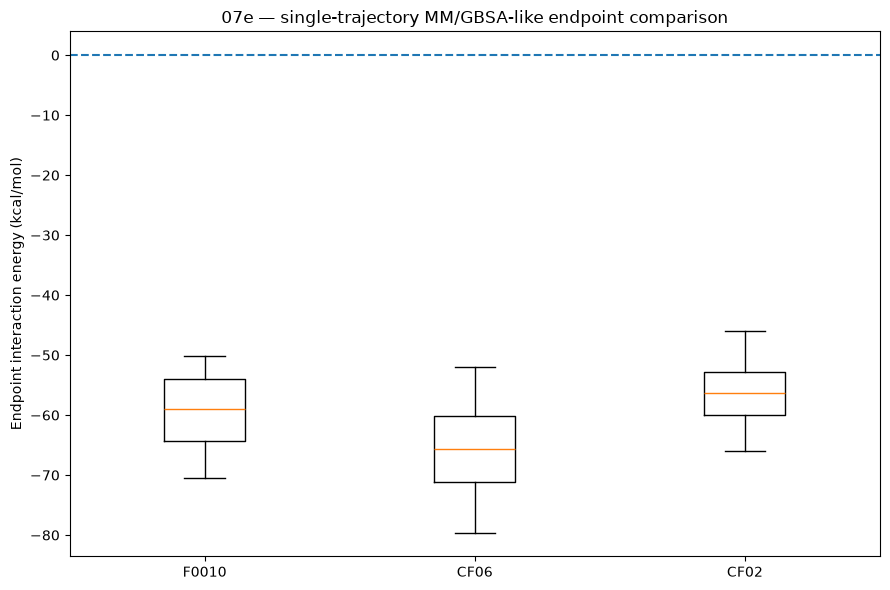

In [17]:
plt.figure(figsize=(9, 6))

data = [
    energy_df.loc[
        energy_df["candidate"]
        == name,
        "delta_E_endpoint_kcal_mol",
    ].values
    for name in CANDIDATES
]

plt.boxplot(

    data,

    tick_labels=list(CANDIDATES.keys()),

)

plt.axhline(
    0,
    linestyle="--",
)

plt.ylabel(
    "Endpoint interaction energy (kcal/mol)"
)
plt.title(
    "07e — single-trajectory MM/GBSA-like endpoint comparison"
)
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "endpoint_energy_boxplot.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 17. Energy across trajectory

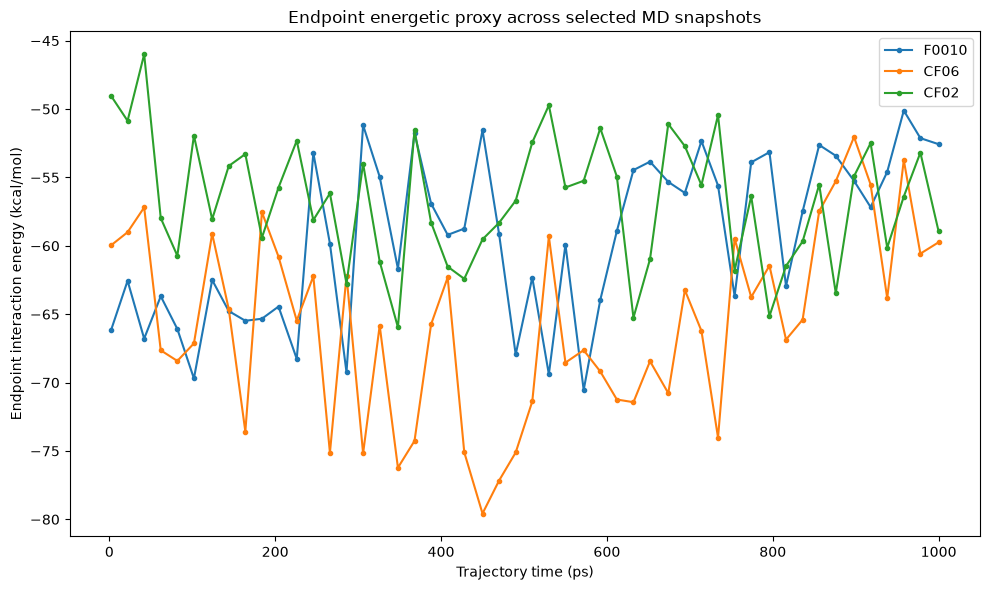

In [18]:
plt.figure(figsize=(10, 6))

for name in CANDIDATES:

    df = energy_df[
        energy_df["candidate"]
        == name
    ]

    plt.plot(
        df["time_ps"],
        df[
            "delta_E_endpoint_kcal_mol"
        ],
        marker="o",
        markersize=3,
        label=name,
    )

plt.xlabel("Trajectory time (ps)")
plt.ylabel(
    "Endpoint interaction energy (kcal/mol)"
)
plt.title(
    "Endpoint energetic proxy across selected MD snapshots"
)
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "endpoint_energy_timeseries.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 18. Relative energetic difference vs F0010

In [19]:
reference_mean = float(
    summary_df.loc[
        summary_df["candidate"]
        == "F0010",
        "mean_delta_E_endpoint_kcal_mol",
    ].iloc[0]
)

relative_df = summary_df[
    [
        "candidate",
        "sequence",
        "mean_delta_E_endpoint_kcal_mol",
        "sd_delta_E_endpoint_kcal_mol",
        "sem_delta_E_endpoint_kcal_mol",
    ]
].copy()

relative_df[
    "delta_vs_F0010_kcal_mol"
] = (
    relative_df[
        "mean_delta_E_endpoint_kcal_mol"
    ]
    - reference_mean
)

relative_df[
    "interpretation_vs_F0010"
] = np.where(
    relative_df[
        "delta_vs_F0010_kcal_mol"
    ] < 0,
    "more favorable endpoint proxy",
    np.where(
        relative_df[
            "delta_vs_F0010_kcal_mol"
        ] > 0,
        "less favorable endpoint proxy",
        "reference",
    ),
)

relative_df.to_csv(
    TABLE_DIR
    / "07e_relative_to_F0010.csv",
    index=False,
)

display(relative_df)


,candidate,sequence,mean_delta_E_endpoint_kcal_mol,sd_delta_E_endpoint_kcal_mol,sem_delta_E_endpoint_kcal_mol,delta_vs_F0010_kcal_mol,interpretation_vs_F0010
0,CF06,IGERCQYRELR,-65.661216,6.801657,0.961900,-6.203512,more favorable endpoint proxy
1,F0010,IGERCQYRDLK,-59.457704,5.958218,0.842619,0.000000,reference
2,CF02,IGERSQYRELK,-56.619600,4.628475,0.654565,2.838104,less favorable endpoint proxy


## 19. Integrate 07d dynamic metrics

This section combines the new endpoint-energy proxy with the raw dynamic
metrics from 07d.

The purpose is not to manufacture a single absolute score, but to see whether
the **dynamic** and **energetic** rankings point in the same direction.


In [20]:
comparison_07d_file = (
    INPUT_ROOT
    / "07d_selected_peptide_MD_comparison.csv"
)

if comparison_07d_file.exists():

    dynamic_07d_df = pd.read_csv(
        comparison_07d_file
    )

    integrated_df = summary_df.merge(
        dynamic_07d_df,
        on=[
            "candidate",
            "sequence",
        ],
        how="left",
    )

    integrated_df.to_csv(
        TABLE_DIR
        / "07e_dynamic_energetic_integration.csv",
        index=False,
    )

    display(
        integrated_df[
            [
                "energetic_rank",
                "candidate",
                "sequence",
                "mean_delta_E_endpoint_kcal_mol",
                "mean_D_CA_RMSD_A",
                "mean_D_CA_RMSF_A",
                "n_persistent_contacts_50pct",
                "mean_contact_persistence",
            ]
        ]
    )

else:
    integrated_df = None

    print(
        "07d comparison CSV not found; "
        "energetic analysis remains valid."
    )


,energetic_rank,candidate,sequence,mean_delta_E_endpoint_kcal_mol,mean_D_CA_RMSD_A,mean_D_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence
0,1,CF06,IGERCQYRELR,-65.661216,1.293427,0.903728,45,0.528545
1,2,F0010,IGERCQYRDLK,-59.457704,1.965916,1.163706,43,0.540519
2,3,CF02,IGERSQYRELK,-56.619600,0.901385,0.737052,43,0.602886


## 20. Bootstrap uncertainty of the mean difference

In [21]:
BOOTSTRAP_REPLICATES = 5000
BOOTSTRAP_SEED = 20260808

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_rows = []

reference_values = (
    energy_df.loc[
        energy_df["candidate"]
        == "F0010",
        "delta_E_endpoint_kcal_mol",
    ]
    .to_numpy()
)

for name in ["CF06", "CF02"]:

    candidate_values = (
        energy_df.loc[
            energy_df["candidate"]
            == name,
            "delta_E_endpoint_kcal_mol",
        ]
        .to_numpy()
    )

    differences = []

    for _ in range(
        BOOTSTRAP_REPLICATES
    ):
        sample_candidate = rng.choice(
            candidate_values,
            size=len(candidate_values),
            replace=True,
        )

        sample_reference = rng.choice(
            reference_values,
            size=len(reference_values),
            replace=True,
        )

        differences.append(
            sample_candidate.mean()
            - sample_reference.mean()
        )

    differences = np.asarray(
        differences
    )

    bootstrap_rows.append({
        "candidate": name,
        "mean_difference_vs_F0010_kcal_mol": differences.mean(),
        "bootstrap_CI95_low": np.percentile(
            differences,
            2.5,
        ),
        "bootstrap_CI95_high": np.percentile(
            differences,
            97.5,
        ),
        "fraction_more_favorable_than_F0010": float(
            np.mean(
                differences < 0
            )
        ),
    })

bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

bootstrap_df.to_csv(
    TABLE_DIR
    / "07e_bootstrap_vs_F0010.csv",
    index=False,
)

display(bootstrap_df)


,candidate,mean_difference_vs_F0010_kcal_mol,bootstrap_CI95_low,bootstrap_CI95_high,fraction_more_favorable_than_F0010
0,CF06,-6.227329,-8.661419,-3.811611,1.0000
1,CF02,2.806083,0.777643,4.830586,0.0024


### Statistical caution

Trajectory snapshots are **time-correlated**, so the bootstrap above should
not be interpreted as a formal independent-sample confidence interval.

It is included only as a descriptive uncertainty diagnostic.

A rigorous uncertainty estimate would use:
- longer simulations;
- multiple independent replicates;
- autocorrelation-aware/block analysis.


## 21. Automatic report

In [22]:
best_candidate = summary_df.iloc[0]["candidate"]

report_lines = [
    "# 07e - Selected Peptide MM/GBSA-like Endpoint Comparison",
    "",
    f"- Source trajectories: 07d / {RUN_07D}",
    f"- Snapshots per candidate: {N_SNAPSHOTS}",
    f"- Protein force field: {PROTEIN_FF}",
    f"- Implicit-solvent model: {SELECTED_IMPLICIT_FF}",
    "",
    "## Endpoint-energy ranking",
]

for row in summary_df.itertuples():
    report_lines.append(
        (
            f"{row.energetic_rank}. {row.candidate} "
            f"({row.sequence}): "
            f"mean ΔE_endpoint = "
            f"{row.mean_delta_E_endpoint_kcal_mol:.3f} "
            f"± {row.sd_delta_E_endpoint_kcal_mol:.3f} kcal/mol "
            f"(SD; n={row.n_snapshots})"
        )
    )

report_lines.extend([
    "",
    f"Best endpoint-energy proxy: {best_candidate}",
    "",
    "## Interpretation",
    (
        "The endpoint estimate is a single-trajectory MM/GBSA-like "
        "comparative proxy. More negative values are treated as more "
        "favorable within this exact protocol."
    ),
    (
        "It is not an absolute binding free energy and does not include "
        "conformational entropy, independent-component relaxation, "
        "replicate simulations or experimental calibration."
    ),
])

if integrated_df is not None:
    report_lines.extend([
        "",
        "## Integration with 07d",
        (
            "The endpoint energetic ranking should be interpreted together "
            "with peptide RMSD, RMSF and persistent-contact metrics from 07d."
        ),
    ])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "07e_MMGBSA_like_endpoint_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(report_text)
print("\nReport:", report_path.resolve())


# 07e - Selected Peptide MM/GBSA-like Endpoint Comparison

- Source trajectories: 07d / production_1ns
- Snapshots per candidate: 50
- Protein force field: amber14/protein.ff14SB.xml
- Implicit-solvent model: implicit/gbn2.xml

## Endpoint-energy ranking
1. CF06 (IGERCQYRELR): mean ΔE_endpoint = -65.661 ± 6.802 kcal/mol (SD; n=50)
2. F0010 (IGERCQYRDLK): mean ΔE_endpoint = -59.458 ± 5.958 kcal/mol (SD; n=50)
3. CF02 (IGERSQYRELK): mean ΔE_endpoint = -56.620 ± 4.628 kcal/mol (SD; n=50)

Best endpoint-energy proxy: CF06

## Interpretation
The endpoint estimate is a single-trajectory MM/GBSA-like comparative proxy. More negative values are treated as more favorable within this exact protocol.
It is not an absolute binding free energy and does not include conformational entropy, independent-component relaxation, replicate simulations or experimental calibration.

## Integration with 07d
The endpoint energetic ranking should be interpreted together with peptide RMSD, RMSF and persistent-con

# 22. How to interpret the result

The strongest outcome is **cross-method convergence**.

For example:

```text
CF02 best/near-best in 07d dynamic stability
+
CF02 best/near-best in 07e endpoint energetic proxy
```

would strengthen its prioritization.

Conversely:

```text
good dynamics
+
unfavorable endpoint energy
```

would indicate that structural stability alone should not be interpreted as
stronger binding.

---

## Next Pipeline 3 step

After 07e, Pipeline 3 has covered:

```text
07a  dimer setup/equilibration
07b  1 ns dimer MD + contact persistence
07c  hotspot/MD integration
07d  selected peptide 1 ns MD comparison
07e  snapshot endpoint energetic comparison
```

At that point the molecular-dynamics branch is sufficiently complete for a
prototype project.

The next major project branch can therefore move to:

```text
Pipeline 4 — ESM-2 / ProteinMPNN
```

unless a longer/repeated MD validation is desired first.
